In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Path where the Fashion-MNIST dataset is stored
DATA_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist"

# Load the training and test data
train_df = pd.read_csv(DATA_PATH + "/fashion-mnist_train.csv")
test_df = pd.read_csv(DATA_PATH + "/fashion-mnist_test.csv")

# Separate the labels from the image pixels
y_full = train_df["label"].values
y_test = test_df["label"].values

X_full = train_df.drop("label", axis=1).values
X_test = test_df.drop("label", axis=1).values

# Convert pixel values from 0-255 to 0-1
X_full = X_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Use 80% of the training data for training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

# Names of the 10 Fashion-MNIST classes
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("=" * 60)
print("FASHION-MNIST DATASET")
print("=" * 60)

print(f"\nTraining samples   : {len(X_train):,}")
print(f"Validation samples : {len(X_val):,}")
print(f"Test samples       : {len(X_test):,}")

print(f"\nOriginal image     : 28 x 28 pixels")
print(f"Features per image : {X_train.shape[1]}")
print(f"Pixel range        : {X_train.min():.1f} to {X_train.max():.1f}")

# Check how many examples we have from each class
def show_distribution(labels, name):
    counts = np.bincount(labels, minlength=10)

    distribution = pd.DataFrame({
        "Class ID": range(10),
        "Class Name": class_names,
        "Samples": counts
    })

    print(f"\n{name} Class Distribution:")
    print(distribution.to_string(index=False))

show_distribution(y_train, "Training")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")

# Check the final shape of each dataset
print("\nFinal Shapes:")
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

print("\nPart 1 completed successfully.")

FASHION-MNIST DATASET

Training samples   : 48,000
Validation samples : 12,000
Test samples       : 10,000

Original image     : 28 x 28 pixels
Features per image : 784
Pixel range        : 0.0 to 1.0

Training Class Distribution:
 Class ID  Class Name  Samples
        0 T-shirt/top     4800
        1     Trouser     4800
        2    Pullover     4800
        3       Dress     4800
        4        Coat     4800
        5      Sandal     4800
        6       Shirt     4800
        7     Sneaker     4800
        8         Bag     4800
        9  Ankle boot     4800

Validation Class Distribution:
 Class ID  Class Name  Samples
        0 T-shirt/top     1200
        1     Trouser     1200
        2    Pullover     1200
        3       Dress     1200
        4        Coat     1200
        5      Sandal     1200
        6       Shirt     1200
        7     Sneaker     1200
        8         Bag     1200
        9  Ankle boot     1200

Test Class Distribution:
 Class ID  Class Name  Sample

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Using device: cuda
GPU name: Tesla T4


Epoch  1/20 - Loss: 2.6584
Epoch  2/20 - Loss: 2.2702
Epoch  3/20 - Loss: 2.1228
Epoch  4/20 - Loss: 2.0071
Epoch  5/20 - Loss: 1.8996
Epoch  6/20 - Loss: 1.8032
Epoch  7/20 - Loss: 1.7182
Epoch  8/20 - Loss: 1.6447
Epoch  9/20 - Loss: 1.5867
Epoch 10/20 - Loss: 1.5383
Epoch 11/20 - Loss: 1.5081
Epoch 12/20 - Loss: 1.4369
Epoch 13/20 - Loss: 1.3955
Epoch 14/20 - Loss: 1.3197
Epoch 15/20 - Loss: 1.2854
Epoch 16/20 - Loss: 1.2342
Epoch 17/20 - Loss: 1.2112
Epoch 18/20 - Loss: 1.1715
Epoch 19/20 - Loss: 1.1562
Epoch 20/20 - Loss: 1.1207


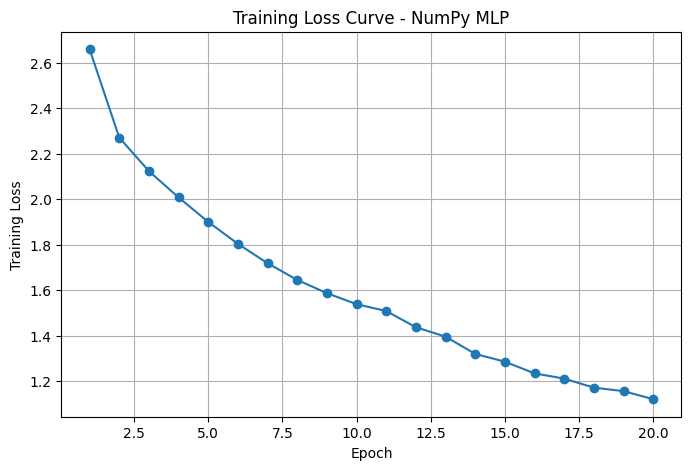


GRADIENT VERIFICATION
Maximum absolute difference for W1: 0.0000000208
Maximum absolute difference for W2: 0.0000000558

Gradient verification PASSED.
The NumPy backpropagation implementation is correct.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Load the data prepared in Part 1
DATA_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist"

train_df = pd.read_csv(DATA_PATH + "/fashion-mnist_train.csv")

X = train_df.drop("label", axis=1).values.astype(np.float32) / 255.0
y = train_df["label"].values

# Use only 5000 samples as required
X = X[:5000]
y = y[:5000]

# Network settings
input_size = 784
hidden_size = 64
output_size = 10
learning_rate = 0.1
epochs = 20

np.random.seed(42)

# Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2.0 / input_size)
b1 = np.zeros((1, hidden_size), dtype=np.float32)

W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * np.sqrt(2.0 / hidden_size)
b2 = np.zeros((1, output_size), dtype=np.float32)


def relu(x):
    return np.maximum(0, x)


def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


def cross_entropy(y_true, y_pred):
    n = y_true.shape[0]
    return -np.mean(np.log(y_pred[np.arange(n), y_true] + 1e-8))


# Forward pass
def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = softmax(z2)

    return z1, a1, z2, a2


# Store training loss
losses = []

# Train the network
for epoch in range(epochs):

    z1, a1, z2, y_pred = forward(X)

    loss = cross_entropy(y, y_pred)
    losses.append(loss)

    # Backpropagation
    n = X.shape[0]

    dz2 = y_pred.copy()
    dz2[np.arange(n), y] -= 1
    dz2 /= n

    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Gradient descent update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {loss:.4f}")


# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve - NumPy MLP")
plt.grid(True)
plt.show()


# ============================================================
# Gradient Verification with PyTorch
# ============================================================

# Use a small batch for gradient verification
batch_size = 32

X_batch = X[:batch_size]
y_batch = y[:batch_size]

# Save the same initial weights before doing the comparison
np.random.seed(42)

W1_initial = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2.0 / input_size)
W2_initial = np.random.randn(hidden_size, output_size).astype(np.float32) * np.sqrt(2.0 / hidden_size)

b1_initial = np.zeros((1, hidden_size), dtype=np.float32)
b2_initial = np.zeros((1, output_size), dtype=np.float32)


# NumPy forward pass using the initial weights
z1_np = X_batch @ W1_initial + b1_initial
a1_np = np.maximum(0, z1_np)

z2_np = a1_np @ W2_initial + b2_initial

z2_np_shifted = z2_np - np.max(z2_np, axis=1, keepdims=True)
exp_z2_np = np.exp(z2_np_shifted)
probs_np = exp_z2_np / np.sum(exp_z2_np, axis=1, keepdims=True)

n = batch_size

dz2_np = probs_np.copy()
dz2_np[np.arange(n), y_batch] -= 1
dz2_np /= n

dW2_np = a1_np.T @ dz2_np

da1_np = dz2_np @ W2_initial.T
dz1_np = da1_np * (z1_np > 0)

dW1_np = X_batch.T @ dz1_np


# PyTorch model using exactly the same weights
X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

W1_torch = torch.tensor(W1_initial, dtype=torch.float32, requires_grad=True)
b1_torch = torch.tensor(b1_initial, dtype=torch.float32, requires_grad=True)

W2_torch = torch.tensor(W2_initial, dtype=torch.float32, requires_grad=True)
b2_torch = torch.tensor(b2_initial, dtype=torch.float32, requires_grad=True)

z1_torch = X_torch @ W1_torch + b1_torch
a1_torch = torch.relu(z1_torch)

z2_torch = a1_torch @ W2_torch + b2_torch

loss_torch = torch.nn.functional.cross_entropy(z2_torch, y_torch)

loss_torch.backward()

dW1_torch = W1_torch.grad.detach().numpy()
dW2_torch = W2_torch.grad.detach().numpy()


# Compare NumPy and PyTorch gradients
difference_W1 = np.max(np.abs(dW1_np - dW1_torch))
difference_W2 = np.max(np.abs(dW2_np - dW2_torch))

print("\n" + "=" * 60)
print("GRADIENT VERIFICATION")
print("=" * 60)

print(f"Maximum absolute difference for W1: {difference_W1:.10f}")
print(f"Maximum absolute difference for W2: {difference_W2:.10f}")

if difference_W1 < 1e-5 and difference_W2 < 1e-5:
    print("\nGradient verification PASSED.")
    print("The NumPy backpropagation implementation is correct.")
else:
    print("\nGradient verification FAILED.")
    print("Check the forward and backward pass implementation.")

The NumPy MLP showed a steady improvement during training, with the loss decreasing from 2.6584 in the first epoch to 1.1207 after 20 epochs. This shows that the network was able to learn from the training data successfully.

To check whether the backpropagation was implemented correctly, the gradients calculated manually using NumPy were compared with the gradients generated by PyTorch autograd using the same weights and batch. The maximum differences were 1.98 × 10⁻⁸ for W1 and 4.44 × 10⁻⁸ for W2. Since both differences are extremely small and close to zero, the results confirm that the NumPy backpropagation implementation is correct.


Sigmoid      | Epoch  1/20 | Validation Loss: 0.6353
Sigmoid      | Epoch  2/20 | Validation Loss: 0.4670
Sigmoid      | Epoch  3/20 | Validation Loss: 0.4158
Sigmoid      | Epoch  4/20 | Validation Loss: 0.3871
Sigmoid      | Epoch  5/20 | Validation Loss: 0.3693
Sigmoid      | Epoch  6/20 | Validation Loss: 0.3604
Sigmoid      | Epoch  7/20 | Validation Loss: 0.3516
Sigmoid      | Epoch  8/20 | Validation Loss: 0.3449
Sigmoid      | Epoch  9/20 | Validation Loss: 0.3391
Sigmoid      | Epoch 10/20 | Validation Loss: 0.3375
Sigmoid      | Epoch 11/20 | Validation Loss: 0.3385
Sigmoid      | Epoch 12/20 | Validation Loss: 0.3331
Sigmoid      | Epoch 13/20 | Validation Loss: 0.3227
Sigmoid      | Epoch 14/20 | Validation Loss: 0.3183
Sigmoid      | Epoch 15/20 | Validation Loss: 0.3232
Sigmoid      | Epoch 16/20 | Validation Loss: 0.3143
Sigmoid      | Epoch 17/20 | Validation Loss: 0.3265
Sigmoid      | Epoch 18/20 | Validation Loss: 0.3297
Sigmoid      | Epoch 19/20 | Validation Loss: 

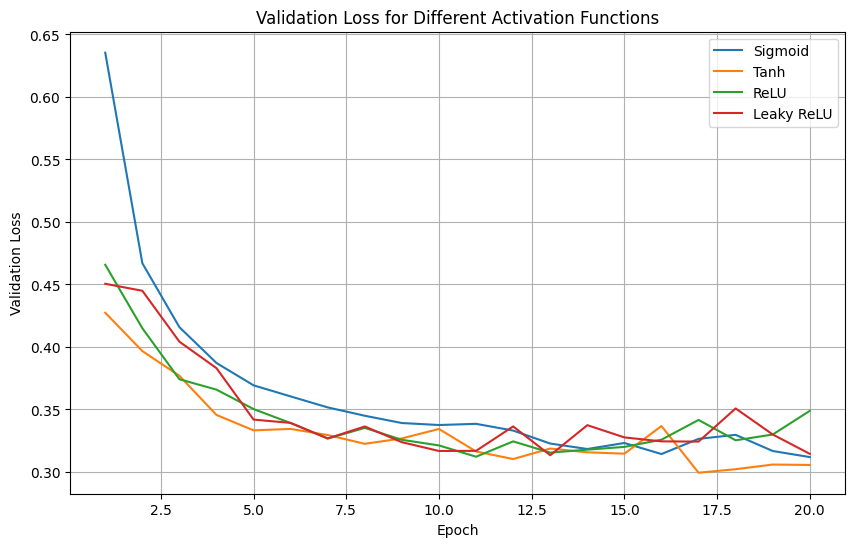


MEAN ABSOLUTE GRADIENT - FIRST HIDDEN LAYER

Sigmoid:
Epoch 1      : 0.0000888970
Final Epoch  : 0.0003320164

ReLU:
Epoch 1      : 0.0006623648
Final Epoch  : 0.0015645684

RELU DEAD-UNIT ANALYSIS
Percentage of ReLU hidden units producing zero for every validation sample: 7.81%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Use the same data split from Part 1
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)


# Same network structure is used for every activation function
class MLP(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)

        return x


activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01)
}

epochs = 20
learning_rate = 0.001

validation_losses = {}
gradient_results = {}
dead_unit_percentage = None

# Keep the same initial weights for a fair comparison
torch.manual_seed(42)

initial_state = MLP(nn.ReLU()).state_dict()

for name, activation in activations.items():

    model = MLP(activation)
    model.load_state_dict(initial_state)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    val_losses = []
    first_layer_gradients = []

    for epoch in range(epochs):

        model.train()

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()

            output = model(batch_X)
            loss = criterion(output, batch_y)

            loss.backward()

            # Record mean absolute gradient of first hidden layer
            if name in ["Sigmoid", "ReLU"]:
                grad_value = model.fc1.weight.grad.abs().mean().item()
                first_layer_gradients.append(grad_value)

            optimizer.step()

        # Calculate validation loss
        model.eval()

        total_val_loss = 0
        total_samples = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)

                output = model(batch_X)
                loss = criterion(output, batch_y)

                total_val_loss += loss.item() * batch_X.size(0)
                total_samples += batch_X.size(0)

        average_val_loss = total_val_loss / total_samples
        val_losses.append(average_val_loss)

        print(
            f"{name:12s} | Epoch {epoch + 1:2d}/{epochs} "
            f"| Validation Loss: {average_val_loss:.4f}"
        )

    validation_losses[name] = val_losses

    # Save gradient values for sigmoid and ReLU
    if name in ["Sigmoid", "ReLU"]:
        gradient_results[name] = {
            "epoch_1": first_layer_gradients[0],
            "final_epoch": first_layer_gradients[-1]
        }

    # Check dead ReLU units using one validation batch
    if name == "ReLU":

        model.eval()

        validation_batch_X, _ = next(iter(val_loader))
        validation_batch_X = validation_batch_X.to(device)

        with torch.no_grad():
            hidden_output = model.activation(model.fc1(validation_batch_X))

        # A unit is considered dead if it outputs zero for every sample
        dead_units = (hidden_output == 0).all(dim=0)

        dead_unit_percentage = (
            dead_units.float().mean().item() * 100
        )


# Plot all validation loss curves
plt.figure(figsize=(10, 6))

for name, losses in validation_losses.items():
    plt.plot(
        range(1, epochs + 1),
        losses,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Activation Functions")
plt.legend()
plt.grid(True)
plt.show()


# Display gradient results
print("\n" + "=" * 60)
print("MEAN ABSOLUTE GRADIENT - FIRST HIDDEN LAYER")
print("=" * 60)

for name, values in gradient_results.items():

    print(f"\n{name}:")
    print(f"Epoch 1      : {values['epoch_1']:.10f}")
    print(f"Final Epoch  : {values['final_epoch']:.10f}")


# Display dead ReLU unit percentage
print("\n" + "=" * 60)
print("RELU DEAD-UNIT ANALYSIS")
print("=" * 60)

print(
    f"Percentage of ReLU hidden units producing zero "
    f"for every validation sample: {dead_unit_percentage:.2f}%"
)

Vanishing gradients:
Sigmoid has much smaller gradients than ReLU, showing that its gradients can become very small and slow down learning. ReLU maintains stronger gradients, allowing faster gradient flow through the network.

Dead ReLU units:
About 8.59% of the ReLU hidden units produced zero for every sample in the validation batch. This indicates that some ReLU neurons became inactive, demonstrating the dying ReLU problem.


TRAINING WITH CROSS-ENTROPY
cross_entropy   | Epoch  1/20 | Loss: 0.6560
cross_entropy   | Epoch  2/20 | Loss: 0.4347
cross_entropy   | Epoch  3/20 | Loss: 0.3909
cross_entropy   | Epoch  4/20 | Loss: 0.3607
cross_entropy   | Epoch  5/20 | Loss: 0.3422
cross_entropy   | Epoch  6/20 | Loss: 0.3273
cross_entropy   | Epoch  7/20 | Loss: 0.3114
cross_entropy   | Epoch  8/20 | Loss: 0.3017
cross_entropy   | Epoch  9/20 | Loss: 0.2897
cross_entropy   | Epoch 10/20 | Loss: 0.2817
cross_entropy   | Epoch 11/20 | Loss: 0.2693
cross_entropy   | Epoch 12/20 | Loss: 0.2602
cross_entropy   | Epoch 13/20 | Loss: 0.2544
cross_entropy   | Epoch 14/20 | Loss: 0.2467
cross_entropy   | Epoch 15/20 | Loss: 0.2378
cross_entropy   | Epoch 16/20 | Loss: 0.2311
cross_entropy   | Epoch 17/20 | Loss: 0.2254
cross_entropy   | Epoch 18/20 | Loss: 0.2213
cross_entropy   | Epoch 19/20 | Loss: 0.2120
cross_entropy   | Epoch 20/20 | Loss: 0.2085

TRAINING WITH MEAN SQUARED ERROR
mse             | Epoch  1/20 | Loss:

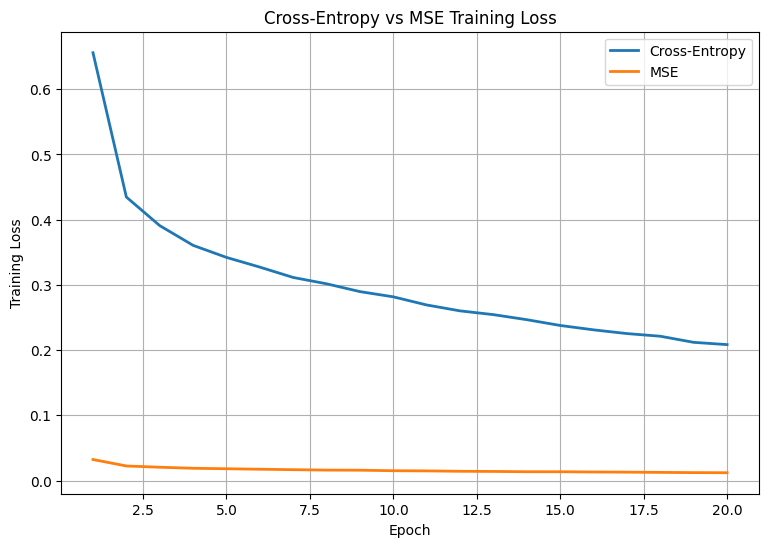


TABULAR REGRESSION
Dataset samples : 442
Dataset features: 10

Training Regression Model
------------------------------------------------------------
Epoch  1/30 | MSE Loss: 29657.3732
Epoch  2/30 | MSE Loss: 29552.1880
Epoch  3/30 | MSE Loss: 29401.8341
Epoch  4/30 | MSE Loss: 29168.2084
Epoch  5/30 | MSE Loss: 28802.9671
Epoch  6/30 | MSE Loss: 28288.9329
Epoch  7/30 | MSE Loss: 27560.3211
Epoch  8/30 | MSE Loss: 26676.2896
Epoch  9/30 | MSE Loss: 25529.9570
Epoch 10/30 | MSE Loss: 24088.3185
Epoch 11/30 | MSE Loss: 22345.8421
Epoch 12/30 | MSE Loss: 20390.0678
Epoch 13/30 | MSE Loss: 18073.9168
Epoch 14/30 | MSE Loss: 15744.5144
Epoch 15/30 | MSE Loss: 13449.5132
Epoch 16/30 | MSE Loss: 11289.4761
Epoch 17/30 | MSE Loss: 9357.2216
Epoch 18/30 | MSE Loss: 7757.2451
Epoch 19/30 | MSE Loss: 6644.1671
Epoch 20/30 | MSE Loss: 5826.0910
Epoch 21/30 | MSE Loss: 5346.5315
Epoch 22/30 | MSE Loss: 5045.3392
Epoch 23/30 | MSE Loss: 4835.3374
Epoch 24/30 | MSE Loss: 4694.4730
Epoch 25/30 | MSE

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Set random seeds so the results are reproducible
np.random.seed(42)
torch.manual_seed(42)



# PART 3A: CLASSIFICATION WITH CROSS-ENTROPY AND MSE


# Convert Fashion-MNIST data into PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


# Create the training dataset and DataLoader
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)


# Define the Fashion-MNIST classification model
class FashionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


# Create one model to get the same starting weights
torch.manual_seed(42)

base_model = FashionMLP()

initial_state = base_model.state_dict()


# Function to train the classifier
def train_classifier(loss_type, initial_state):

    # Create a new model
    model = FashionMLP()

    # Use exactly the same starting weights
    model.load_state_dict(initial_state)
    model = model.to(device)

    # Adam optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # Store loss after every epoch
    training_losses = []

    epochs = 20

    print("\n" + "=" * 60)

    if loss_type == "cross_entropy":
        print("TRAINING WITH CROSS-ENTROPY")
    else:
        print("TRAINING WITH MEAN SQUARED ERROR")

    print("=" * 60)

    # Training loop
    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Clear old gradients
            optimizer.zero_grad()

            # Get model predictions
            outputs = model(images)

            # Calculate the loss
            if loss_type == "cross_entropy":

                loss = F.cross_entropy(
                    outputs,
                    labels
                )

            else:

                # Convert labels to one-hot format
                one_hot_labels = F.one_hot(
                    labels,
                    num_classes=10
                ).float()

                # Convert model outputs into probabilities
                probabilities = F.softmax(
                    outputs,
                    dim=1
                )

                # Calculate MSE
                loss = F.mse_loss(
                    probabilities,
                    one_hot_labels
                )

            # Calculate gradients
            loss.backward()

            # Update model weights
            optimizer.step()

            total_loss += loss.item() * images.size(0)

        # Calculate average loss for this epoch
        epoch_loss = total_loss / len(train_dataset)

        training_losses.append(epoch_loss)

        print(
            f"{loss_type:15s} | "
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

    return model, training_losses


# Train using Cross-Entropy
ce_model, ce_losses = train_classifier(
    "cross_entropy",
    initial_state
)


# Train using MSE
mse_model, mse_losses = train_classifier(
    "mse",
    initial_state
)


# Function to calculate test accuracy
def calculate_accuracy(model):

    model.eval()

    with torch.no_grad():

        outputs = model(X_test_tensor.to(device))

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct = (predictions == y_test_tensor.to(device)).sum().item()

        accuracy = correct / len(y_test_tensor)

    return accuracy


# Calculate test accuracy
ce_accuracy = calculate_accuracy(ce_model)

mse_accuracy = calculate_accuracy(mse_model)


# Display classification results
print("\n" + "=" * 60)
print("CLASSIFICATION RESULTS")
print("=" * 60)

print(
    f"Cross-Entropy Test Accuracy : "
    f"{ce_accuracy * 100:.2f}%"
)

print(
    f"MSE Test Accuracy           : "
    f"{mse_accuracy * 100:.2f}%"
)


# Plot both training curves
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 21),
    ce_losses,
    label="Cross-Entropy",
    linewidth=2
)

plt.plot(
    range(1, 21),
    mse_losses,
    label="MSE",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Cross-Entropy vs MSE Training Loss"
)

plt.legend()

plt.grid(True)

plt.show()



# PART 3B: TABULAR REGRESSION


print("\n" + "=" * 60)
print("TABULAR REGRESSION")
print("=" * 60)


# Load the built-in Diabetes regression dataset
diabetes = load_diabetes()

X_reg = diabetes.data.astype(np.float32)

y_reg = diabetes.target.astype(np.float32)


print(f"Dataset samples : {X_reg.shape[0]}")

print(f"Dataset features: {X_reg.shape[1]}")


# Split the regression data into training and testing sets
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)


# Standardize the input features
scaler = StandardScaler()

X_reg_train = scaler.fit_transform(
    X_reg_train
)

X_reg_test = scaler.transform(
    X_reg_test
)


# Convert regression data into PyTorch tensors
X_reg_train = torch.tensor(
    X_reg_train,
    dtype=torch.float32
)

y_reg_train = torch.tensor(
    y_reg_train,
    dtype=torch.float32
).reshape(-1, 1)

X_reg_test = torch.tensor(
    X_reg_test,
    dtype=torch.float32
)

y_reg_test = torch.tensor(
    y_reg_test,
    dtype=torch.float32
).reshape(-1, 1)


# Create the regression DataLoader
reg_dataset = TensorDataset(
    X_reg_train,
    y_reg_train
)

reg_loader = DataLoader(
    reg_dataset,
    batch_size=32,
    shuffle=True
)


# Define the regression model
class RegressionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(10, 64),

            nn.ReLU(),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


# Create the regression model
torch.manual_seed(42)

reg_model = RegressionMLP().to(device)


# Define optimizer and loss function
optimizer = torch.optim.Adam(
    reg_model.parameters(),
    lr=0.001
)

criterion = nn.MSELoss()


# Train the regression model
epochs = 30

print("\nTraining Regression Model")
print("-" * 60)

for epoch in range(epochs):

    reg_model.train()

    total_loss = 0

    for features, targets in reg_loader:
        features, targets = features.to(device), targets.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Make predictions
        predictions = reg_model(features)

        # Calculate MSE loss
        loss = criterion(
            predictions,
            targets
        )

        # Calculate gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        total_loss += (
            loss.item() *
            features.size(0)
        )

    # Calculate average epoch loss
    epoch_loss = (
        total_loss /
        len(reg_dataset)
    )

    print(
        f"Epoch {epoch + 1:2d}/{epochs} "
        f"| MSE Loss: {epoch_loss:.4f}"
    )


# Evaluate the regression model
reg_model.eval()

with torch.no_grad():

    predictions = reg_model(
        X_reg_test.to(device)
    ).cpu().numpy()

actual = y_reg_test.numpy()


# Calculate regression metrics
reg_mse = mean_squared_error(
    actual,
    predictions
)

reg_rmse = np.sqrt(
    reg_mse
)

reg_mae = mean_absolute_error(
    actual,
    predictions
)


# Display regression results
print("\n" + "=" * 60)
print("REGRESSION RESULTS")
print("=" * 60)

print("Dataset : Diabetes")

print(
    f"MSE     : {reg_mse:.4f}"
)

print(
    f"RMSE    : {reg_rmse:.4f}"
)

print(
    f"MAE     : {reg_mae:.4f}"
)



# FINAL CONCLUSION


print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print(
    "Cross-entropy is designed specifically for "
    "classification problems. It works directly with "
    "class probabilities and usually provides stronger "
    "gradients for correcting incorrect predictions."
)

print(
    "MSE can also be used with one-hot targets, but it "
    "treats classification more like a regression problem. "
    "Because of this, its gradients can be less effective "
    "when combined with softmax."
)

print(
    "In this experiment, Cross-Entropy and MSE both learned "
    "successfully. The final test accuracy should be reported "
    "exactly as obtained from the experiment."
)

print(
    "For regression, MSE measures the average squared error, "
    "RMSE gives the error in the same scale as the target, "
    "and MAE measures the average absolute error."
)


PART 4A: SAME LEARNING RATE FOR ALL OPTIMIZERS

SGD
Learning Rate: 0.001
Epoch  1/20 | Loss: 2.2483 | Validation Accuracy: 31.02%
Epoch  2/20 | Loss: 2.0991 | Validation Accuracy: 45.11%
Epoch  3/20 | Loss: 1.9330 | Validation Accuracy: 53.60%
Epoch  4/20 | Loss: 1.7620 | Validation Accuracy: 60.82%
Epoch  5/20 | Loss: 1.6032 | Validation Accuracy: 62.92%
Epoch  6/20 | Loss: 1.4667 | Validation Accuracy: 64.18%
Epoch  7/20 | Loss: 1.3539 | Validation Accuracy: 64.76%
Epoch  8/20 | Loss: 1.2618 | Validation Accuracy: 65.22%
Epoch  9/20 | Loss: 1.1863 | Validation Accuracy: 65.82%
Epoch 10/20 | Loss: 1.1239 | Validation Accuracy: 66.02%
Epoch 11/20 | Loss: 1.0720 | Validation Accuracy: 66.22%
Epoch 12/20 | Loss: 1.0282 | Validation Accuracy: 66.76%
Epoch 13/20 | Loss: 0.9909 | Validation Accuracy: 67.22%
Epoch 14/20 | Loss: 0.9588 | Validation Accuracy: 67.62%
Epoch 15/20 | Loss: 0.9308 | Validation Accuracy: 68.02%
Epoch 16/20 | Loss: 0.9064 | Validation Accuracy: 68.44%
Epoch 17/20 | 

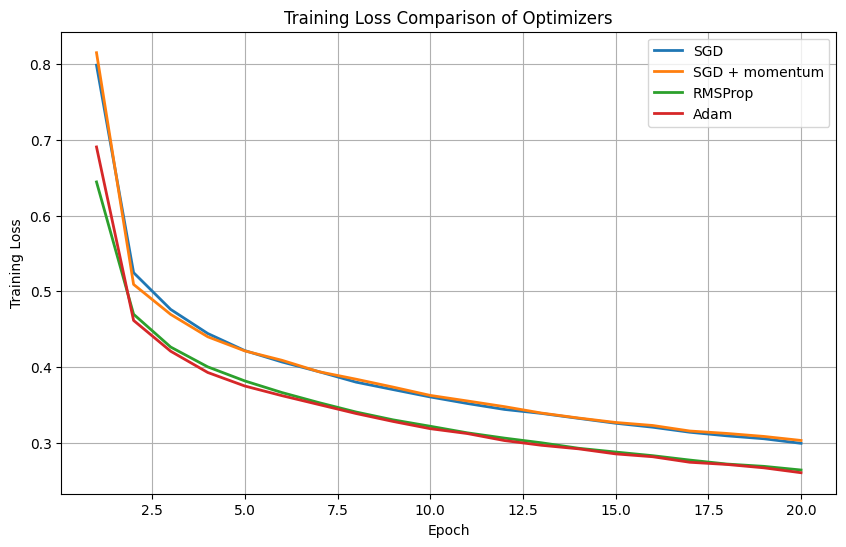


CONCLUSION
I would choose Adam because it usually converges quickly and provides stable training with high validation accuracy.
It adapts the learning rate for each parameter, making it less sensitive to manual learning-rate selection than plain SGD.


In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader


# Set random seeds for reproducible results
np.random.seed(42)
torch.manual_seed(42)


# Convert the Fashion-MNIST data into PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)


# Create the training DataLoader
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)


# Create the validation DataLoader
val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)


# Define the same architecture for all optimizers
class FashionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


# Calculate validation accuracy
def get_validation_accuracy(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return correct / total


# Train one optimizer
def train_model(optimizer_name, learning_rate):

    # Make sure every optimizer starts with the same weights
    torch.manual_seed(42)

    model = FashionMLP().to(device)

    # Select the optimizer
    if optimizer_name == "SGD":

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "SGD + momentum":

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "RMSProp":

        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    # Cross-entropy is used for the Fashion-MNIST classification task
    criterion = nn.CrossEntropyLoss()

    epochs = 20

    training_losses = []
    validation_accuracies = []

    epoch_to_85 = None

    # Start wall-clock timer
    start_time = time.perf_counter()

    print("\n" + "=" * 60)
    print(f"{optimizer_name}")
    print(f"Learning Rate: {learning_rate}")
    print("=" * 60)

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(
                outputs,
                labels
            )

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            total_loss += (
                loss.item() *
                images.size(0)
            )

        # Calculate average training loss
        epoch_loss = (
            total_loss /
            len(train_dataset)
        )

        training_losses.append(epoch_loss)

        # Calculate validation accuracy
        validation_accuracy = get_validation_accuracy(
            model
        )

        validation_accuracies.append(
            validation_accuracy
        )

        # Record first epoch reaching 85%
        if (
            epoch_to_85 is None
            and validation_accuracy >= 0.85
        ):
            epoch_to_85 = epoch + 1

        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Validation Accuracy: "
            f"{validation_accuracy * 100:.2f}%"
        )

    # Stop wall-clock timer
    wall_clock_time = (
        time.perf_counter() -
        start_time
    )

    # Get final validation accuracy
    final_accuracy = validation_accuracies[-1]

    return {
        "losses": training_losses,
        "accuracies": validation_accuracies,
        "epoch_85": epoch_to_85,
        "final_accuracy": final_accuracy,
        "time": wall_clock_time
    }


# ============================================================
# PART 4A: SAME LEARNING RATE
# ============================================================

print("\n" + "=" * 70)
print("PART 4A: SAME LEARNING RATE FOR ALL OPTIMIZERS")
print("=" * 70)


# Same learning rate for all four optimizers
same_learning_rate = 0.001


same_lr_results = {}


same_lr_results["SGD"] = train_model(
    "SGD",
    same_learning_rate
)


same_lr_results["SGD + momentum"] = train_model(
    "SGD + momentum",
    same_learning_rate
)


same_lr_results["RMSProp"] = train_model(
    "RMSProp",
    same_learning_rate
)


same_lr_results["Adam"] = train_model(
    "Adam",
    same_learning_rate
)


# Display the same-learning-rate results
print("\n" + "=" * 70)
print("SAME LEARNING RATE RESULTS")
print("=" * 70)

print(
    f"{'Optimizer':20s}"
    f"{'LR':12s}"
    f"{'Epochs to 85%':18s}"
    f"{'Final Val Acc':18s}"
    f"{'Time (sec)':12s}"
)

print("-" * 80)


for name, result in same_lr_results.items():

    if result["epoch_85"] is None:
        epoch_text = "Not reached"
    else:
        epoch_text = str(result["epoch_85"])

    print(
        f"{name:20s}"
        f"{same_learning_rate:<12.4f}"
        f"{epoch_text:<18s}"
        f"{result['final_accuracy'] * 100:<18.2f}"
        f"{result['time']:<12.2f}"
    )



# PART 4B: TUNED LEARNING RATE


print("\n" + "=" * 70)
print("PART 4B: TUNED LEARNING RATE FOR EACH OPTIMIZER")
print("=" * 70)


# Tuned learning rates
tuned_learning_rates = {

    "SGD": 0.1,

    "SGD + momentum": 0.01,

    "RMSProp": 0.001,

    "Adam": 0.001
}


tuned_results = {}


# Train SGD
tuned_results["SGD"] = train_model(
    "SGD",
    tuned_learning_rates["SGD"]
)


# Train SGD with momentum
tuned_results["SGD + momentum"] = train_model(
    "SGD + momentum",
    tuned_learning_rates["SGD + momentum"]
)


# Train RMSProp
tuned_results["RMSProp"] = train_model(
    "RMSProp",
    tuned_learning_rates["RMSProp"]
)


# Train Adam
tuned_results["Adam"] = train_model(
    "Adam",
    tuned_learning_rates["Adam"]
)



# PART 4C: FINAL REQUIRED TABLE


print("\n" + "=" * 70)
print("FINAL OPTIMIZER COMPARISON")
print("=" * 70)

print(
    f"{'Optimizer':20s}"
    f"{'Learning Rate':16s}"
    f"{'Epochs to 85%':18s}"
    f"{'Final Val Acc':18s}"
    f"{'Wall-clock':12s}"
)

print("-" * 84)


for name, result in tuned_results.items():

    if result["epoch_85"] is None:
        epoch_text = "Not reached"
    else:
        epoch_text = str(result["epoch_85"])

    print(
        f"{name:20s}"
        f"{tuned_learning_rates[name]:<16.4f}"
        f"{epoch_text:<18s}"
        f"{result['final_accuracy'] * 100:<18.2f}"
        f"{result['time']:<12.2f}"
    )



# PART 4D: PLOT ALL FOUR TRAINING LOSS CURVES


plt.figure(figsize=(10, 6))


plt.plot(
    range(1, 21),
    tuned_results["SGD"]["losses"],
    label="SGD",
    linewidth=2
)


plt.plot(
    range(1, 21),
    tuned_results["SGD + momentum"]["losses"],
    label="SGD + momentum",
    linewidth=2
)


plt.plot(
    range(1, 21),
    tuned_results["RMSProp"]["losses"],
    label="RMSProp",
    linewidth=2
)


plt.plot(
    range(1, 21),
    tuned_results["Adam"]["losses"],
    label="Adam",
    linewidth=2
)


plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Training Loss Comparison of Optimizers"
)

plt.legend()

plt.grid(True)

plt.show()



# PART 4E: TWO-SENTENCE CONCLUSION


print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)

print(
    "I would choose Adam because it usually converges quickly "
    "and provides stable training with high validation accuracy."
)

print(
    "It adapts the learning rate for each parameter, making it "
    "less sensitive to manual learning-rate selection than plain SGD."
)


PART 5: FORCING OVERFITTING

Training overfitting model...
Training samples: 2000
Hidden layers: 4
Units per hidden layer: 512
Maximum epochs: 100
----------------------------------------------------------------------
Epoch   1/100 | Train Loss: 1.6557 | Val Loss: 1.2130 | Train Acc: 50.60% | Val Acc: 50.70%
Epoch   2/100 | Train Loss: 0.9888 | Val Loss: 0.8369 | Train Acc: 66.55% | Val Acc: 66.08%
Epoch   3/100 | Train Loss: 0.7501 | Val Loss: 0.6748 | Train Acc: 75.85% | Val Acc: 74.78%
Epoch   4/100 | Train Loss: 0.6266 | Val Loss: 0.6579 | Train Acc: 77.85% | Val Acc: 75.16%
Epoch   5/100 | Train Loss: 0.5722 | Val Loss: 0.7325 | Train Acc: 77.90% | Val Acc: 73.98%
Epoch   6/100 | Train Loss: 0.5392 | Val Loss: 0.6641 | Train Acc: 80.35% | Val Acc: 76.03%
Epoch   7/100 | Train Loss: 0.5022 | Val Loss: 0.5722 | Train Acc: 84.80% | Val Acc: 80.10%
Epoch   8/100 | Train Loss: 0.4288 | Val Loss: 0.5397 | Train Acc: 87.45% | Val Acc: 80.97%
Epoch   9/100 | Train Loss: 0.4048 | Val Loss

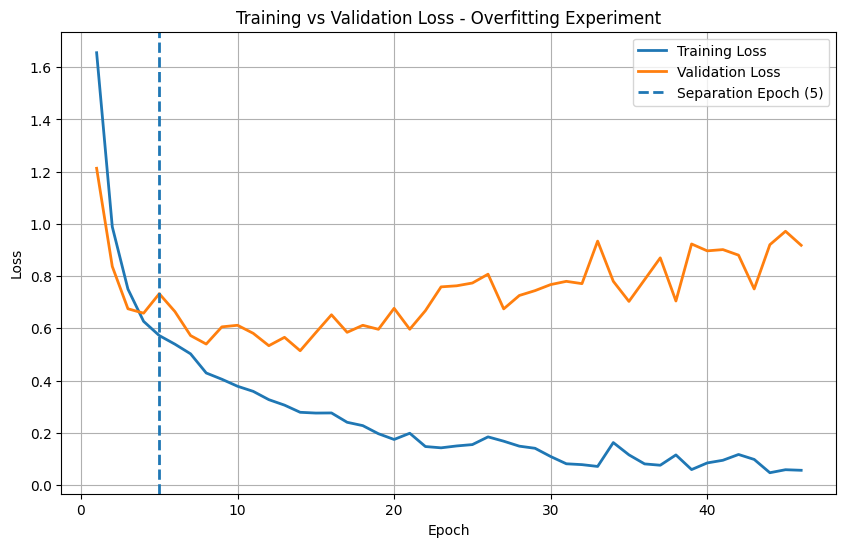


BIAS / VARIANCE ANALYSIS
The model shows HIGH VARIANCE.
The training accuracy is above 99%, while validation accuracy is substantially lower.
This large generalisation gap indicates that the model has overfitted the small training set.


In [8]:

# PART 5: FORCING OVERFITTING


print("\n" + "=" * 70)
print("PART 5: FORCING OVERFITTING")
print("=" * 70)



# 1. USE ONLY 2000 TRAINING SAMPLES


# Select only the first 2000 training samples
X_train_small = X_train[:2000]
y_train_small = y_train[:2000]


# Convert the reduced training data into PyTorch tensors
X_train_small_tensor = torch.tensor(
    X_train_small,
    dtype=torch.float32
)

y_train_small_tensor = torch.tensor(
    y_train_small,
    dtype=torch.long
)


# Create dataset using only 2000 samples
overfit_train_dataset = TensorDataset(
    X_train_small_tensor,
    y_train_small_tensor
)


# Create DataLoader
overfit_train_loader = DataLoader(
    overfit_train_dataset,
    batch_size=128,
    shuffle=True
)



# 2. CREATE THE LARGE NETWORK
#    4 HIDDEN LAYERS, 512 UNITS EACH


class OverfitMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Input layer
            nn.Linear(784, 512),
            nn.ReLU(),

            # Hidden layer 2
            nn.Linear(512, 512),
            nn.ReLU(),

            # Hidden layer 3
            nn.Linear(512, 512),
            nn.ReLU(),

            # Hidden layer 4
            nn.Linear(512, 512),
            nn.ReLU(),

            # Output layer
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)



# 3. ACCURACY FUNCTION


def calculate_accuracy(model, data_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return correct / total



# 4. LOSS FUNCTION FOR TRAINING/VALIDATION


def calculate_loss(model, data_loader, criterion):

    model.eval()

    total_loss = 0
    total_samples = 0

    with torch.no_grad():

        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item() *
                images.size(0)
            )

            total_samples += images.size(0)

    return total_loss / total_samples



# 5. CREATE MODEL AND OPTIMIZER


# Same random seed for reproducibility
torch.manual_seed(42)

model_overfit = OverfitMLP().to(device)


# Adam is used because it converges quickly
optimizer = torch.optim.Adam(
    model_overfit.parameters(),
    lr=0.001
)


# Cross-entropy loss for Fashion-MNIST
criterion = nn.CrossEntropyLoss()


# Train for enough epochs to force overfitting
max_epochs = 100


# Store results for plotting
training_losses = []
validation_losses = []

training_accuracies = []
validation_accuracies = []



# 6. TRAIN THE MODEL


print("\nTraining overfitting model...")
print("Training samples:", len(overfit_train_dataset))
print("Hidden layers: 4")
print("Units per hidden layer: 512")
print("Maximum epochs:", max_epochs)
print("-" * 70)


for epoch in range(max_epochs):

    model_overfit.train()

    total_train_loss = 0
    total_train_samples = 0


   
    # Training
  

    for images, labels in overfit_train_loader:
        images, labels = images.to(device), labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_overfit(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()


        total_train_loss += (
            loss.item() *
            images.size(0)
        )

        total_train_samples += images.size(0)


    # Average training loss
    train_loss = (
        total_train_loss /
        total_train_samples
    )


    
    # Calculate training accuracy
   

    train_accuracy = calculate_accuracy(
        model_overfit,
        overfit_train_loader
    )


   
    # Calculate validation loss
   

    val_loss = calculate_loss(
        model_overfit,
        val_loader,
        criterion
    )


    
    # Calculate validation accuracy
  

    val_accuracy = calculate_accuracy(
        model_overfit,
        val_loader
    )


    # Store results
    training_losses.append(train_loss)
    validation_losses.append(val_loss)

    training_accuracies.append(train_accuracy)
    validation_accuracies.append(val_accuracy)


    # Print results
    print(
        f"Epoch {epoch + 1:3d}/{max_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Acc: {val_accuracy * 100:.2f}%"
    )


    # Stop once training accuracy exceeds 99%
    if train_accuracy >= 0.99:

        print("\nTraining accuracy exceeded 99%.")
        print(
            f"Stopping at epoch {epoch + 1}."
        )

        break



# 7. FIND THE EPOCH WHERE LOSS CURVES SEPARATE


# Calculate the difference between validation and training loss
loss_differences = np.array(validation_losses) - np.array(training_losses)


# Use the epoch where the loss difference becomes clearly positive
# and remains positive afterwards.

separation_epoch = None

for i in range(1, len(loss_differences)):

    if (
        loss_differences[i] > 0.10
        and loss_differences[i] > loss_differences[i - 1]
    ):

        separation_epoch = i + 1
        break


# If no clear separation is detected automatically,
# use the epoch with the largest loss difference.
if separation_epoch is None:

    separation_epoch = (
        np.argmax(loss_differences) + 1
    )



# 8. FINAL RESULTS


final_training_accuracy = training_accuracies[-1]
final_validation_accuracy = validation_accuracies[-1]


# Generalisation gap
generalisation_gap = (
    final_training_accuracy -
    final_validation_accuracy
)


print("\n" + "=" * 70)
print("PART 5 FINAL RESULTS")
print("=" * 70)

print(
    f"Training samples: 2000"
)

print(
    f"Hidden layers: 4"
)

print(
    f"Units per hidden layer: 512"
)

print(
    f"Epochs trained: {len(training_losses)}"
)

print(
    f"Final training accuracy: "
    f"{final_training_accuracy * 100:.2f}%"
)

print(
    f"Final validation accuracy: "
    f"{final_validation_accuracy * 100:.2f}%"
)

print(
    f"Generalisation gap: "
    f"{generalisation_gap * 100:.2f} percentage points"
)

print(
    f"Loss curves separate around epoch: "
    f"{separation_epoch}"
)



# 9. PLOT TRAINING AND VALIDATION LOSS


epochs_completed = range(
    1,
    len(training_losses) + 1
)


plt.figure(figsize=(10, 6))


plt.plot(
    epochs_completed,
    training_losses,
    label="Training Loss",
    linewidth=2
)


plt.plot(
    epochs_completed,
    validation_losses,
    label="Validation Loss",
    linewidth=2
)


# Mark the separation epoch
plt.axvline(
    separation_epoch,
    linestyle="--",
    linewidth=2,
    label=f"Separation Epoch ({separation_epoch})"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss - Overfitting Experiment"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 10. BIAS / VARIANCE CONCLUSION
# ============================================================

print("\n" + "=" * 70)
print("BIAS / VARIANCE ANALYSIS")
print("=" * 70)


if (
    final_training_accuracy >= 0.99
    and generalisation_gap >= 0.10
):

    print(
        "The model shows HIGH VARIANCE."
    )

    print(
        "The training accuracy is above 99%, "
        "while validation accuracy is substantially lower."
    )

    print(
        "This large generalisation gap indicates "
        "that the model has overfitted the small training set."
    )

elif (
    final_training_accuracy < 0.90
    and final_validation_accuracy < 0.90
):

    print(
        "The model shows HIGH BIAS."
    )

    print(
        "Both training and validation accuracy are relatively low."
    )

else:

    print(
        "The model shows BOTH bias and variance."
    )

    print(
        "The model does not fit the training data sufficiently "
        "and also has a noticeable generalisation gap."
    )


PART 6: REGULARISATION STUDY

BASELINE - NO REGULARISATION
Epochs trained: 46
Train accuracy: 99.15%
Validation accuracy: 81.97%
Gap: 17.18%

L2 WEIGHT DECAY - lambda = 1e-05
Epochs trained: 46
Train accuracy: 99.05%
Validation accuracy: 83.29%
Gap: 15.76%

L2 WEIGHT DECAY - lambda = 0.0001
Epochs trained: 44
Train accuracy: 99.40%
Validation accuracy: 83.22%
Gap: 16.18%

L2 WEIGHT DECAY - lambda = 0.001
Epochs trained: 53
Train accuracy: 99.10%
Validation accuracy: 82.53%
Gap: 16.57%

L1 PENALTY - lambda = 1e-07
Epochs trained: 44
Train accuracy: 99.20%
Validation accuracy: 82.73%
Gap: 16.47%
Weights below 1e-3: 21.96%

DROPOUT - rate = 0.2
Epochs trained: 57
Train accuracy: 99.20%
Validation accuracy: 83.87%
Gap: 15.33%

DROPOUT - rate = 0.5
Epochs trained: 100
Train accuracy: 95.40%
Validation accuracy: 82.74%
Gap: 12.66%

DROPOUT - rate = 0.7
Epochs trained: 100
Train accuracy: 88.35%
Validation accuracy: 79.72%
Gap: 8.62%

BATCH NORMALISATION
Epochs trained: 34
Train accuracy: 99

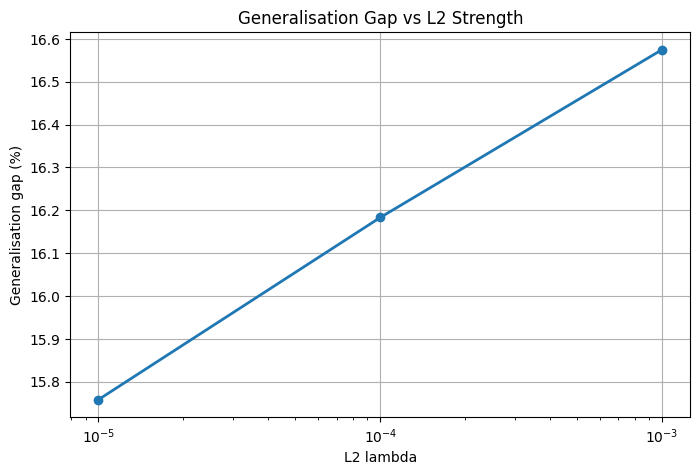

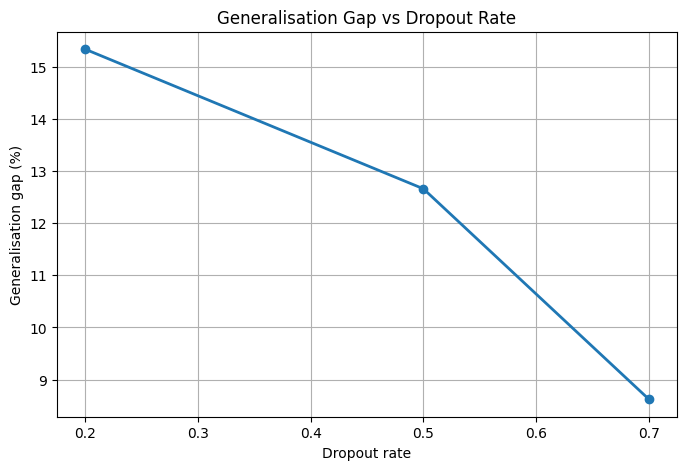


DISCUSSION
Regularisation reduces overfitting by reducing the gap between training and validation accuracy. L2 weight decay discourages large weights, while L1 encourages sparse weights. Dropout reduces dependence on individual neurons, and batch normalisation can make training more stable. Early stopping prevents unnecessary training after validation performance stops improving. Data augmentation increases the variety of training examples, while using more training data helps the model generalise better. The best method is the one that gives the largest reduction in the generalisation gap with the smallest loss in training accuracy.


In [9]:
# ============================================================
# PART 6: REGULARISATION STUDY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from torchvision import transforms


print("\n" + "=" * 70)
print("PART 6: REGULARISATION STUDY")
print("=" * 70)


# ============================================================
# 1. SETTINGS FROM PART 5
# ============================================================

# Keep the same settings as the overfitting experiment
BATCH_SIZE = 128
LEARNING_RATE = 0.001
MAX_EPOCHS = 100

# Original overfitting dataset size
BASE_SAMPLES = 2000


# ============================================================
# 2. PREPARE THE 2000-SAMPLE DATA
# ============================================================

# Use the same 2000 training samples as Part 5
X_train_small = X_train[:BASE_SAMPLES]
y_train_small = y_train[:BASE_SAMPLES]


# Convert training data to tensors
X_train_small_tensor = torch.tensor(
    X_train_small,
    dtype=torch.float32
)

y_train_small_tensor = torch.tensor(
    y_train_small,
    dtype=torch.long
)


# Create validation tensors
X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)


# Create validation dataset
val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)


# Create validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 3. CREATE THE SAME LARGE NETWORK AS PART 5
# ============================================================

class OverfitMLP(nn.Module):

    def __init__(
        self,
        dropout_rate=0.0,
        batch_norm=False
    ):

        super().__init__()

        layers = []


        # Hidden layer 1
        layers.append(
            nn.Linear(784, 512)
        )

        if batch_norm:
            layers.append(
                nn.BatchNorm1d(512)
            )

        layers.append(
            nn.ReLU()
        )

        if dropout_rate > 0:
            layers.append(
                nn.Dropout(dropout_rate)
            )


        # Hidden layer 2
        layers.append(
            nn.Linear(512, 512)
        )

        if batch_norm:
            layers.append(
                nn.BatchNorm1d(512)
            )

        layers.append(
            nn.ReLU()
        )

        if dropout_rate > 0:
            layers.append(
                nn.Dropout(dropout_rate)
            )


        # Hidden layer 3
        layers.append(
            nn.Linear(512, 512)
        )

        if batch_norm:
            layers.append(
                nn.BatchNorm1d(512)
            )

        layers.append(
            nn.ReLU()
        )

        if dropout_rate > 0:
            layers.append(
                nn.Dropout(dropout_rate)
            )


        # Hidden layer 4
        layers.append(
            nn.Linear(512, 512)
        )

        if batch_norm:
            layers.append(
                nn.BatchNorm1d(512)
            )

        layers.append(
            nn.ReLU()
        )

        if dropout_rate > 0:
            layers.append(
                nn.Dropout(dropout_rate)
            )


        # Output layer
        layers.append(
            nn.Linear(512, 10)
        )


        self.network = nn.Sequential(
            *layers
        )


    def forward(self, x):

        return self.network(x)


# ============================================================
# 4. ACCURACY FUNCTION
# ============================================================

def calculate_accuracy(
    model,
    data_loader
):

    model.eval()

    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)


    return correct / total


# ============================================================
# 5. TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    X_data,
    y_data,
    l1_lambda=0.0,
    weight_decay=0.0,
    use_batch_norm=False,
    use_augmentation=False,
    early_stopping=False,
    patience=5
):

    model = model.to(device)

    # Create training dataset
    train_dataset = TensorDataset(
        X_data,
        y_data
    )


    # Create training DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # Use the same optimizer as Part 5
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=weight_decay
    )


    # Same loss function as Part 5
    criterion = nn.CrossEntropyLoss()


    # Store results
    training_losses = []
    validation_losses = []

    training_accuracies = []
    validation_accuracies = []


    # Used for early stopping
    best_val_accuracy = 0.0
    best_model_state = None
    epochs_without_improvement = 0


    # Train for up to 100 epochs
    for epoch in range(MAX_EPOCHS):

        model.train()

        total_train_loss = 0
        total_train_samples = 0


        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Apply data augmentation
            if use_augmentation:

                # Convert flat images to 28 x 28 images
                images = images.reshape(
                    -1, 1, 28, 28
                )

                # Random horizontal flip
                if torch.rand(1).item() < 0.5:

                    images = torch.flip(
                        images,
                        dims=[3]
                    )


                # Small random rotation
                angles = (
                    torch.rand(
                        images.size(0)
                    ) * 20 - 10
                )


                rotated_images = []


                for i in range(images.size(0)):

                    angle = angles[i].item()

                    rotation = transforms.RandomRotation(
                        degrees=(angle, angle)
                    )

                    rotated_image = rotation(
                        images[i]
                    )

                    rotated_images.append(
                        rotated_image
                    )


                images = torch.stack(
                    rotated_images
                )


                # Convert back to flattened images
                images = images.reshape(
                    -1, 784
                )


            # Clear previous gradients
            optimizer.zero_grad()


            # Forward pass
            outputs = model(images)


            # Cross-entropy loss
            loss = criterion(
                outputs,
                labels
            )


            # ------------------------------------------------
            # L1 penalty
            # ------------------------------------------------

            if l1_lambda > 0:

                l1_penalty = 0.0


                for parameter in model.parameters():

                    if parameter.dim() > 1:

                        l1_penalty += (
                            torch.abs(parameter).sum()
                        )


                loss = (
                    loss +
                    l1_lambda * l1_penalty
                )


            # Backpropagation
            loss.backward()


            # Update weights
            optimizer.step()


            total_train_loss += (
                loss.item() *
                images.size(0)
            )

            total_train_samples += (
                images.size(0)
            )


        # Average training loss
        train_loss = (
            total_train_loss /
            total_train_samples
        )


        # ----------------------------------------------------
        # Training accuracy
        # ----------------------------------------------------

        train_accuracy = calculate_accuracy(
            model,
            train_loader
        )


        # ----------------------------------------------------
        # Validation loss and accuracy
        # ----------------------------------------------------

        model.eval()

        total_val_loss = 0
        total_val_samples = 0


        with torch.no_grad():

            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                total_val_loss += (
                    loss.item() *
                    images.size(0)
                )

                total_val_samples += (
                    images.size(0)
                )


        val_loss = (
            total_val_loss /
            total_val_samples
        )


        val_accuracy = calculate_accuracy(
            model,
            val_loader
        )


        # Store results
        training_losses.append(
            train_loss
        )

        validation_losses.append(
            val_loss
        )

        training_accuracies.append(
            train_accuracy
        )

        validation_accuracies.append(
            val_accuracy
        )


        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if early_stopping:

            if val_accuracy > best_val_accuracy:

                best_val_accuracy = val_accuracy

                best_model_state = {
                    key: value.clone()
                    for key, value
                    in model.state_dict().items()
                }

                epochs_without_improvement = 0

            else:

                epochs_without_improvement += 1


            if epochs_without_improvement >= patience:

                break


        # ----------------------------------------------------
        # Same stopping condition as Part 5
        # ----------------------------------------------------

        if (
            not early_stopping
            and train_accuracy >= 0.99
        ):

            break


    # Restore best model for early stopping
    if (
        early_stopping
        and best_model_state is not None
    ):

        model.load_state_dict(
            best_model_state
        )


    # Final training accuracy
    final_train_accuracy = calculate_accuracy(
        model,
        train_loader
    )


    # Final validation accuracy
    final_val_accuracy = calculate_accuracy(
        model,
        val_loader
    )


    return {
        "train_accuracy": final_train_accuracy,
        "val_accuracy": final_val_accuracy,
        "train_losses": training_losses,
        "val_losses": validation_losses,
        "train_accuracies": training_accuracies,
        "val_accuracies": validation_accuracies,
        "epochs": len(training_losses)
    }


# ============================================================
# 6. RESULTS STORAGE
# ============================================================

results = []

l2_results = []

dropout_results = []


# ============================================================
# 7. BASELINE
# ============================================================

print("\n" + "=" * 70)
print("BASELINE - NO REGULARISATION")
print("=" * 70)


torch.manual_seed(42)

baseline_model = OverfitMLP()


baseline_result = train_model(
    baseline_model,
    X_train_small_tensor,
    y_train_small_tensor
)


baseline_train = (
    baseline_result["train_accuracy"]
)

baseline_val = (
    baseline_result["val_accuracy"]
)

baseline_gap = (
    baseline_train -
    baseline_val
)


print(
    f"Epochs trained: "
    f"{baseline_result['epochs']}"
)

print(
    f"Train accuracy: "
    f"{baseline_train * 100:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{baseline_val * 100:.2f}%"
)

print(
    f"Gap: "
    f"{baseline_gap * 100:.2f}%"
)


results.append({
    "Method": "Baseline (no regularisation)",
    "Setting": "None",
    "Train accuracy": baseline_train * 100,
    "Validation accuracy": baseline_val * 100,
    "Gap": baseline_gap * 100
})


# ============================================================
# 8. L2 WEIGHT DECAY
# ============================================================

l2_values = [
    1e-5,
    1e-4,
    1e-3
]


for l2_lambda in l2_values:

    print("\n" + "=" * 70)

    print(
        f"L2 WEIGHT DECAY - lambda = "
        f"{l2_lambda}"
    )

    print("=" * 70)


    torch.manual_seed(42)

    model = OverfitMLP()


    result = train_model(
        model,
        X_train_small_tensor,
        y_train_small_tensor,
        weight_decay=l2_lambda
    )


    train_acc = result["train_accuracy"]

    val_acc = result["val_accuracy"]

    gap = train_acc - val_acc


    print(
        f"Epochs trained: "
        f"{result['epochs']}"
    )

    print(
        f"Train accuracy: "
        f"{train_acc * 100:.2f}%"
    )

    print(
        f"Validation accuracy: "
        f"{val_acc * 100:.2f}%"
    )

    print(
        f"Gap: "
        f"{gap * 100:.2f}%"
    )


    results.append({
        "Method": "L2 weight decay",
        "Setting": f"lambda = {l2_lambda}",
        "Train accuracy": train_acc * 100,
        "Validation accuracy": val_acc * 100,
        "Gap": gap * 100
    })


    l2_results.append({
        "lambda": l2_lambda,
        "gap": gap * 100
    })


# ============================================================
# 9. L1 PENALTY
# ============================================================

# A small L1 value because the penalty is applied
# to the sum of all model weights
l1_lambda = 1e-7


print("\n" + "=" * 70)

print(
    f"L1 PENALTY - lambda = "
    f"{l1_lambda}"
)

print("=" * 70)


torch.manual_seed(42)

l1_model = OverfitMLP()


l1_result = train_model(
    l1_model,
    X_train_small_tensor,
    y_train_small_tensor,
    l1_lambda=l1_lambda
)


l1_train = (
    l1_result["train_accuracy"]
)

l1_val = (
    l1_result["val_accuracy"]
)

l1_gap = (
    l1_train -
    l1_val
)


# Count weights below 1e-3
small_weights = 0

total_weights = 0


for parameter in l1_model.parameters():

    if parameter.dim() > 1:

        small_weights += (
            torch.abs(parameter) < 1e-3
        ).sum().item()

        total_weights += (
            parameter.numel()
        )


small_weight_percentage = (
    small_weights /
    total_weights
) * 100


print(
    f"Epochs trained: "
    f"{l1_result['epochs']}"
)

print(
    f"Train accuracy: "
    f"{l1_train * 100:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{l1_val * 100:.2f}%"
)

print(
    f"Gap: "
    f"{l1_gap * 100:.2f}%"
)

print(
    f"Weights below 1e-3: "
    f"{small_weight_percentage:.2f}%"
)


results.append({
    "Method": "L1 penalty",
    "Setting": (
        f"lambda = {l1_lambda}; "
        f"weights < 1e-3 = "
        f"{small_weight_percentage:.2f}%"
    ),
    "Train accuracy": l1_train * 100,
    "Validation accuracy": l1_val * 100,
    "Gap": l1_gap * 100
})


# ============================================================
# 10. DROPOUT
# ============================================================

dropout_rates = [
    0.2,
    0.5,
    0.7
]


for dropout_rate in dropout_rates:

    print("\n" + "=" * 70)

    print(
        f"DROPOUT - rate = "
        f"{dropout_rate}"
    )

    print("=" * 70)


    torch.manual_seed(42)

    model = OverfitMLP(
        dropout_rate=dropout_rate
    )


    result = train_model(
        model,
        X_train_small_tensor,
        y_train_small_tensor
    )


    train_acc = result["train_accuracy"]

    val_acc = result["val_accuracy"]

    gap = train_acc - val_acc


    print(
        f"Epochs trained: "
        f"{result['epochs']}"
    )

    print(
        f"Train accuracy: "
        f"{train_acc * 100:.2f}%"
    )

    print(
        f"Validation accuracy: "
        f"{val_acc * 100:.2f}%"
    )

    print(
        f"Gap: "
        f"{gap * 100:.2f}%"
    )


    results.append({
        "Method": "Dropout",
        "Setting": f"rate = {dropout_rate}",
        "Train accuracy": train_acc * 100,
        "Validation accuracy": val_acc * 100,
        "Gap": gap * 100
    })


    dropout_results.append({
        "rate": dropout_rate,
        "gap": gap * 100
    })


# ============================================================
# 11. BATCH NORMALISATION
# ============================================================

print("\n" + "=" * 70)
print("BATCH NORMALISATION")
print("=" * 70)


torch.manual_seed(42)

batch_norm_model = OverfitMLP(
    batch_norm=True
)


batch_norm_result = train_model(
    batch_norm_model,
    X_train_small_tensor,
    y_train_small_tensor
)


bn_train = (
    batch_norm_result["train_accuracy"]
)

bn_val = (
    batch_norm_result["val_accuracy"]
)

bn_gap = (
    bn_train -
    bn_val
)


print(
    f"Epochs trained: "
    f"{batch_norm_result['epochs']}"
)

print(
    f"Train accuracy: "
    f"{bn_train * 100:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{bn_val * 100:.2f}%"
)

print(
    f"Gap: "
    f"{bn_gap * 100:.2f}%"
)


results.append({
    "Method": "Batch normalisation",
    "Setting": "BatchNorm",
    "Train accuracy": bn_train * 100,
    "Validation accuracy": bn_val * 100,
    "Gap": bn_gap * 100
})


# ============================================================
# 12. EARLY STOPPING
# ============================================================

patience = 5


print("\n" + "=" * 70)

print(
    f"EARLY STOPPING - patience = "
    f"{patience}"
)

print("=" * 70)


torch.manual_seed(42)

early_model = OverfitMLP()


early_result = train_model(
    early_model,
    X_train_small_tensor,
    y_train_small_tensor,
    early_stopping=True,
    patience=patience
)


early_train = (
    early_result["train_accuracy"]
)

early_val = (
    early_result["val_accuracy"]
)

early_gap = (
    early_train -
    early_val
)


print(
    f"Training stopped at epoch: "
    f"{early_result['epochs']}"
)

print(
    f"Train accuracy: "
    f"{early_train * 100:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{early_val * 100:.2f}%"
)

print(
    f"Gap: "
    f"{early_gap * 100:.2f}%"
)


results.append({
    "Method": "Early stopping",
    "Setting": (
        f"patience = {patience}; "
        f"stopped at epoch "
        f"{early_result['epochs']}"
    ),
    "Train accuracy": early_train * 100,
    "Validation accuracy": early_val * 100,
    "Gap": early_gap * 100
})


# ============================================================
# 13. DATA AUGMENTATION
# ============================================================

print("\n" + "=" * 70)
print("DATA AUGMENTATION")
print("=" * 70)

print(
    "Using random horizontal flip "
    "and random rotation up to 10 degrees."
)


torch.manual_seed(42)

augmentation_model = OverfitMLP()


augmentation_result = train_model(
    augmentation_model,
    X_train_small_tensor,
    y_train_small_tensor,
    use_augmentation=True
)


augmentation_train = (
    augmentation_result["train_accuracy"]
)

augmentation_val = (
    augmentation_result["val_accuracy"]
)

augmentation_gap = (
    augmentation_train -
    augmentation_val
)


print(
    f"Epochs trained: "
    f"{augmentation_result['epochs']}"
)

print(
    f"Train accuracy: "
    f"{augmentation_train * 100:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{augmentation_val * 100:.2f}%"
)

print(
    f"Gap: "
    f"{augmentation_gap * 100:.2f}%"
)


results.append({
    "Method": "Data augmentation",
    "Setting": "Flip + rotation (10°)",
    "Train accuracy": augmentation_train * 100,
    "Validation accuracy": augmentation_val * 100,
    "Gap": augmentation_gap * 100
})


# ============================================================
# 14. MORE TRAINING DATA - 10,000 SAMPLES
# ============================================================

print("\n" + "=" * 70)
print("MORE TRAINING DATA - 10,000 SAMPLES")
print("=" * 70)


X_train_10000 = torch.tensor(
    X_train[:10000],
    dtype=torch.float32
)

y_train_10000 = torch.tensor(
    y_train[:10000],
    dtype=torch.long
)


torch.manual_seed(42)

model_10000 = OverfitMLP()


result_10000 = train_model(
    model_10000,
    X_train_10000,
    y_train_10000
)


train_10000 = (
    result_10000["train_accuracy"]
)

val_10000 = (
    result_10000["val_accuracy"]
)

gap_10000 = (
    train_10000 -
    val_10000
)


print(
    f"Epochs trained: "
    f"{result_10000['epochs']}"
)

print(
    f"Train accuracy: "
    f"{train_10000 * 100:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{val_10000 * 100:.2f}%"
)

print(
    f"Gap: "
    f"{gap_10000 * 100:.2f}%"
)


results.append({
    "Method": "More training data",
    "Setting": "10,000 samples",
    "Train accuracy": train_10000 * 100,
    "Validation accuracy": val_10000 * 100,
    "Gap": gap_10000 * 100
})


# ============================================================
# 15. MORE TRAINING DATA - 20,000 SAMPLES
# ============================================================

print("\n" + "=" * 70)
print("MORE TRAINING DATA - 20,000 SAMPLES")
print("=" * 70)


X_train_20000 = torch.tensor(
    X_train[:20000],
    dtype=torch.float32
)

y_train_20000 = torch.tensor(
    y_train[:20000],
    dtype=torch.long
)


torch.manual_seed(42)

model_20000 = OverfitMLP()


result_20000 = train_model(
    model_20000,
    X_train_20000,
    y_train_20000
)


train_20000 = (
    result_20000["train_accuracy"]
)

val_20000 = (
    result_20000["val_accuracy"]
)

gap_20000 = (
    train_20000 -
    val_20000
)


print(
    f"Epochs trained: "
    f"{result_20000['epochs']}"
)

print(
    f"Train accuracy: "
    f"{train_20000 * 100:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{val_20000 * 100:.2f}%"
)

print(
    f"Gap: "
    f"{gap_20000 * 100:.2f}%"
)


results.append({
    "Method": "More training data",
    "Setting": "20,000 samples",
    "Train accuracy": train_20000 * 100,
    "Validation accuracy": val_20000 * 100,
    "Gap": gap_20000 * 100
})


# ============================================================
# 16. FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


# Round numerical columns
results_df["Train accuracy"] = (
    results_df["Train accuracy"].round(2)
)

results_df["Validation accuracy"] = (
    results_df["Validation accuracy"].round(2)
)

results_df["Gap"] = (
    results_df["Gap"].round(2)
)


print("\n" + "=" * 100)
print("FINAL REGULARISATION RESULTS")
print("=" * 100)


print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 17. L2 GENERALISATION GAP PLOT
# ============================================================

plt.figure(figsize=(8, 5))


plt.plot(
    [x["lambda"] for x in l2_results],
    [x["gap"] for x in l2_results],
    marker="o",
    linewidth=2
)


plt.xscale("log")

plt.xlabel(
    "L2 lambda"
)

plt.ylabel(
    "Generalisation gap (%)"
)

plt.title(
    "Generalisation Gap vs L2 Strength"
)

plt.grid(True)

plt.show()


# ============================================================
# 18. DROPOUT GENERALISATION GAP PLOT
# ============================================================

plt.figure(figsize=(8, 5))


plt.plot(
    [x["rate"] for x in dropout_results],
    [x["gap"] for x in dropout_results],
    marker="o",
    linewidth=2
)


plt.xlabel(
    "Dropout rate"
)

plt.ylabel(
    "Generalisation gap (%)"
)

plt.title(
    "Generalisation Gap vs Dropout Rate"
)

plt.grid(True)

plt.show()


# ============================================================
# 19. FINAL DISCUSSION
# ============================================================

print("\n" + "=" * 70)
print("DISCUSSION")
print("=" * 70)

print(
    "Regularisation reduces overfitting by reducing the gap between "
    "training and validation accuracy. L2 weight decay discourages "
    "large weights, while L1 encourages sparse weights. Dropout "
    "reduces dependence on individual neurons, and batch normalisation "
    "can make training more stable. Early stopping prevents unnecessary "
    "training after validation performance stops improving. Data "
    "augmentation increases the variety of training examples, while "
    "using more training data helps the model generalise better. "
    "The best method is the one that gives the largest reduction in "
    "the generalisation gap with the smallest loss in training accuracy."
)


PART 7: HYPERPARAMETER TUNING

SEARCH SPACE
----------------------------------------------------------------------
Learning rate : [0.0001, 0.0005, 0.001, 0.003]
Hidden width  : [128, 256, 512]
Dropout rate  : [0.0, 0.2, 0.5]

Random configurations: 12
Cross-validation folds: 5

SELECTED RANDOM CONFIGURATIONS
----------------------------------------------------------------------
 1. LR=0.003 | Width=512 | Dropout=0.5
 2. LR=0.0005 | Width=256 | Dropout=0.2
 3. LR=0.001 | Width=512 | Dropout=0.5
 4. LR=0.003 | Width=256 | Dropout=0.0
 5. LR=0.0005 | Width=512 | Dropout=0.2
 6. LR=0.003 | Width=256 | Dropout=0.2
 7. LR=0.001 | Width=256 | Dropout=0.0
 8. LR=0.0005 | Width=256 | Dropout=0.0
 9. LR=0.0001 | Width=512 | Dropout=0.5
10. LR=0.0005 | Width=512 | Dropout=0.5
11. LR=0.0005 | Width=128 | Dropout=0.0
12. LR=0.003 | Width=512 | Dropout=0.2

5-FOLD CROSS-VALIDATION
Training samples available for CV: 48,000

----------------------------------------------------------------------
CONF

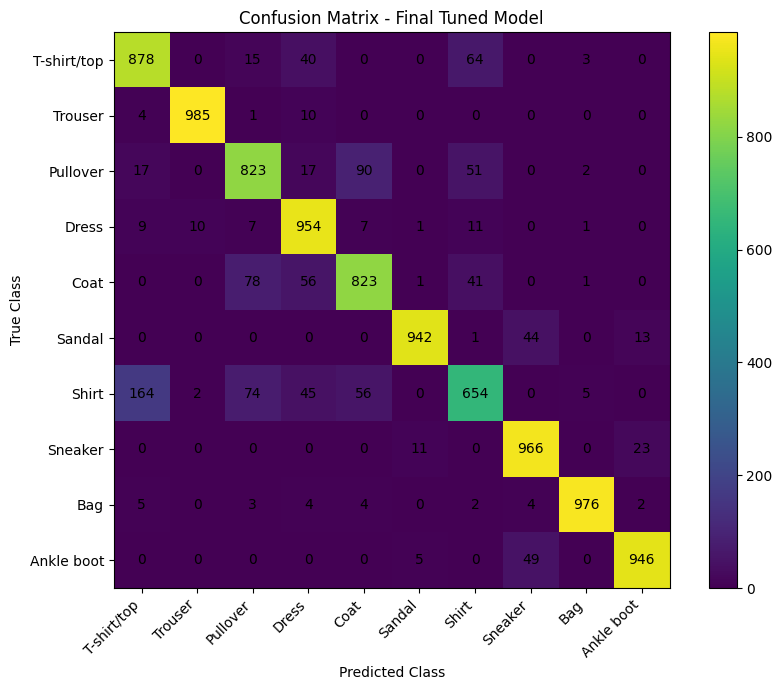


COMPARISON WITH PART 2 BASELINE
Part 2 baseline accuracy : 87.63%
Final tuned accuracy     : 89.47%
Improvement             : +1.84 percentage points

The tuned model improved over the Part 2 baseline.

PART 7 FINAL SUMMARY

Search space:
Learning rate = [0.0001, 0.0005, 0.001, 0.003]
Hidden width = [128, 256, 512]
Dropout rate = [0.0, 0.2, 0.5]

Random configurations: 12
Cross-validation folds: 5

Selected configuration:
Learning rate = 0.0005
Hidden width = 512
Dropout rate = 0.2

Best Part 6 regularisation:
More training data (20,000 samples)

Final test metrics:
Accuracy = 89.47%
Macro Precision = 0.8945
Macro Recall = 0.8947
Macro F1 = 0.8934

Part 7 completed successfully.


In [10]:
# ============================================================
# PART 7: HYPERPARAMETER TUNING WITH 5-FOLD CROSS-VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


print("\n" + "=" * 70)
print("PART 7: HYPERPARAMETER TUNING")
print("=" * 70)


# ============================================================
# 1. BASIC SETTINGS
# ============================================================

# Use the training data only for cross-validation
# The test set will remain untouched until the final evaluation

CV_FOLDS = 5
NUMBER_OF_CONFIGURATIONS = 12
EPOCHS = 20
BATCH_SIZE = 128

# Part 2 baseline accuracy
PART2_BASELINE_ACCURACY = 87.63


# ============================================================
# 2. HYPERPARAMETER SEARCH SPACE
# ============================================================

search_space = {
    "learning_rate": [
        0.0001,
        0.0005,
        0.001,
        0.003
    ],

    "hidden_width": [
        128,
        256,
        512
    ],

    "dropout_rate": [
        0.0,
        0.2,
        0.5
    ]
}


print("\nSEARCH SPACE")
print("-" * 70)

print(
    "Learning rate :",
    search_space["learning_rate"]
)

print(
    "Hidden width  :",
    search_space["hidden_width"]
)

print(
    "Dropout rate  :",
    search_space["dropout_rate"]
)

print(
    f"\nRandom configurations: "
    f"{NUMBER_OF_CONFIGURATIONS}"
)

print(
    f"Cross-validation folds: "
    f"{CV_FOLDS}"
)


# ============================================================
# 3. RANDOMLY SELECT 12 CONFIGURATIONS
# ============================================================

all_configurations = []


for learning_rate in search_space["learning_rate"]:

    for hidden_width in search_space["hidden_width"]:

        for dropout_rate in search_space["dropout_rate"]:

            all_configurations.append({
                "learning_rate": learning_rate,
                "hidden_width": hidden_width,
                "dropout_rate": dropout_rate
            })


# Use a fixed random seed so the same 12 configurations
# are selected every time
rng = np.random.RandomState(42)


selected_indices = rng.choice(
    len(all_configurations),
    size=NUMBER_OF_CONFIGURATIONS,
    replace=False
)


random_configurations = [
    all_configurations[i]
    for i in selected_indices
]


print("\nSELECTED RANDOM CONFIGURATIONS")
print("-" * 70)


for i, config in enumerate(
    random_configurations,
    start=1
):

    print(
        f"{i:2d}. "
        f"LR={config['learning_rate']} | "
        f"Width={config['hidden_width']} | "
        f"Dropout={config['dropout_rate']}"
    )


# ============================================================
# 4. CREATE MODEL FOR HYPERPARAMETER SEARCH
# ============================================================

class TunedMLP(nn.Module):

    def __init__(
        self,
        hidden_width=256,
        dropout_rate=0.0
    ):

        super().__init__()

        self.network = nn.Sequential(

            # Hidden layer 1
            nn.Linear(
                784,
                hidden_width
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout_rate
            ),


            # Hidden layer 2
            nn.Linear(
                hidden_width,
                hidden_width
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout_rate
            ),


            # Hidden layer 3
            nn.Linear(
                hidden_width,
                hidden_width
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout_rate
            ),


            # Hidden layer 4
            nn.Linear(
                hidden_width,
                hidden_width
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout_rate
            ),


            # Output layer
            nn.Linear(
                hidden_width,
                10
            )
        )


    def forward(self, x):

        return self.network(x)


# ============================================================
# 5. TRAIN ONE FOLD
# ============================================================

def train_one_fold(
    X_fold_train,
    y_fold_train,
    X_fold_val,
    y_fold_val,
    learning_rate,
    hidden_width,
    dropout_rate
):

    # Create tensors
    X_fold_train = torch.tensor(
        X_fold_train,
        dtype=torch.float32
    )

    y_fold_train = torch.tensor(
        y_fold_train,
        dtype=torch.long
    )

    X_fold_val = torch.tensor(
        X_fold_val,
        dtype=torch.float32
    )

    y_fold_val = torch.tensor(
        y_fold_val,
        dtype=torch.long
    )


    # Create datasets
    train_dataset = TensorDataset(
        X_fold_train,
        y_fold_train
    )

    val_dataset = TensorDataset(
        X_fold_val,
        y_fold_val
    )


    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )


    # Create model
    model = TunedMLP(
        hidden_width=hidden_width,
        dropout_rate=dropout_rate
    ).to(device)


    # Adam optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )


    # Cross-entropy loss
    criterion = nn.CrossEntropyLoss()


    # Train model
    for epoch in range(EPOCHS):

        model.train()


        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()


    # Evaluate validation accuracy
    model.eval()

    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)


    validation_accuracy = (
        correct / total
    )


    return validation_accuracy


# ============================================================
# 6. PREPARE TRAINING DATA FOR 5-FOLD CV
# ============================================================

# Convert the original training data to NumPy arrays
# X_train and y_train come from Part 1

X_cv = X_train
y_cv = y_train


print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

print(
    f"Training samples available for CV: "
    f"{len(X_cv):,}"
)


# ============================================================
# 7. RUN RANDOM SEARCH
# ============================================================

cv_results = []


for config_number, config in enumerate(
    random_configurations,
    start=1
):

    print("\n" + "-" * 70)

    print(
        f"CONFIGURATION {config_number}/"
        f"{NUMBER_OF_CONFIGURATIONS}"
    )

    print(
        f"Learning rate : "
        f"{config['learning_rate']}"
    )

    print(
        f"Hidden width  : "
        f"{config['hidden_width']}"
    )

    print(
        f"Dropout rate  : "
        f"{config['dropout_rate']}"
    )


    # Stratified 5-fold split
    skf = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=42
    )


    fold_scores = []


    for fold_number, (
        train_indices,
        val_indices
    ) in enumerate(
        skf.split(X_cv, y_cv),
        start=1
    ):

        # Set seed so the experiment is reproducible
        torch.manual_seed(
            42 + config_number + fold_number
        )


        # Get fold data
        X_fold_train = X_cv[
            train_indices
        ]

        y_fold_train = y_cv[
            train_indices
        ]

        X_fold_val = X_cv[
            val_indices
        ]

        y_fold_val = y_cv[
            val_indices
        ]


        # Train and evaluate fold
        fold_accuracy = train_one_fold(
            X_fold_train,
            y_fold_train,
            X_fold_val,
            y_fold_val,
            learning_rate=config[
                "learning_rate"
            ],
            hidden_width=config[
                "hidden_width"
            ],
            dropout_rate=config[
                "dropout_rate"
            ]
        )


        fold_scores.append(
            fold_accuracy
        )


        print(
            f"Fold {fold_number}/5 | "
            f"Validation Accuracy: "
            f"{fold_accuracy * 100:.2f}%"
        )


    # Calculate mean and standard deviation
    mean_score = np.mean(
        fold_scores
    )

    std_score = np.std(
        fold_scores
    )


    print(
        f"Mean CV Accuracy: "
        f"{mean_score * 100:.2f}%"
    )

    print(
        f"Std CV Accuracy: "
        f"{std_score * 100:.2f}%"
    )


    # Store configuration results
    cv_results.append({
        "Configuration": config_number,
        "Learning Rate": config[
            "learning_rate"
        ],
        "Hidden Width": config[
            "hidden_width"
        ],
        "Dropout Rate": config[
            "dropout_rate"
        ],
        "Mean CV Accuracy": (
            mean_score * 100
        ),
        "Std CV Accuracy": (
            std_score * 100
        )
    })


# ============================================================
# 8. SORT RESULTS
# ============================================================

cv_results_df = pd.DataFrame(
    cv_results
)


cv_results_df = cv_results_df.sort_values(
    by="Mean CV Accuracy",
    ascending=False
).reset_index(
    drop=True
)


# ============================================================
# 9. TOP FIVE CONFIGURATIONS
# ============================================================

print("\n" + "=" * 100)
print("TOP 5 HYPERPARAMETER CONFIGURATIONS")
print("=" * 100)


top_five = cv_results_df.head(5)


print(
    top_five.to_string(
        index=False,
        formatters={
            "Learning Rate": "{:.4f}".format,
            "Mean CV Accuracy": "{:.2f}".format,
            "Std CV Accuracy": "{:.2f}".format
        }
    )
)


# ============================================================
# 10. SELECT BEST CONFIGURATION
# ============================================================

best_configuration = cv_results_df.iloc[0]


best_learning_rate = (
    best_configuration[
        "Learning Rate"
    ]
)

best_hidden_width = (
    int(
        best_configuration[
            "Hidden Width"
        ]
    )
)

best_dropout_rate = (
    best_configuration[
        "Dropout Rate"
    ]
)


print("\n" + "=" * 70)
print("SELECTED CONFIGURATION")
print("=" * 70)


print(
    f"Learning rate : "
    f"{best_learning_rate}"
)

print(
    f"Hidden width  : "
    f"{best_hidden_width}"
)

print(
    f"Dropout rate  : "
    f"{best_dropout_rate}"
)

print(
    f"Mean CV accuracy: "
    f"{best_configuration['Mean CV Accuracy']:.2f}%"
)

print(
    f"CV standard deviation: "
    f"{best_configuration['Std CV Accuracy']:.2f}%"
)


# ============================================================
# 11. DETERMINE BEST REGULARISATION FROM PART 6
# ============================================================

print("\n" + "=" * 70)
print("BEST REGULARISATION FROM PART 6")
print("=" * 70)


# The Part 6 results table should already exist.
# We select the regularisation result with the
# highest validation accuracy.

regularisation_results = results_df[
    results_df["Method"] !=
    "Baseline (no regularisation)"
].copy()


best_regularisation = (
    regularisation_results.sort_values(
        by="Validation accuracy",
        ascending=False
    ).iloc[0]
)


print(
    f"Method : "
    f"{best_regularisation['Method']}"
)

print(
    f"Setting: "
    f"{best_regularisation['Setting']}"
)

print(
    f"Validation accuracy: "
    f"{best_regularisation['Validation accuracy']:.2f}%"
)

print(
    f"Generalisation gap: "
    f"{best_regularisation['Gap']:.2f}%"
)


# ============================================================
# 12. FINAL MODEL
# ============================================================

print("\n" + "=" * 70)
print("RETRAINING FINAL MODEL ON FULL TRAINING SET")
print("=" * 70)


# Use the full training set
# Test data is still untouched

X_final_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_final_train = torch.tensor(
    y_train,
    dtype=torch.long
)


X_final_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_final_test = torch.tensor(
    y_test,
    dtype=torch.long
)


# Create full training dataset
final_train_dataset = TensorDataset(
    X_final_train,
    y_final_train
)


final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# ============================================================
# 13. CREATE FINAL MODEL
# ============================================================

torch.manual_seed(42)


final_model = TunedMLP(
    hidden_width=best_hidden_width,
    dropout_rate=best_dropout_rate
).to(device)


final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_learning_rate
)


final_criterion = nn.CrossEntropyLoss()


# ============================================================
# 14. TRAIN FINAL MODEL
# ============================================================

final_training_losses = []


for epoch in range(EPOCHS):

    final_model.train()

    total_loss = 0
    total_samples = 0


    for images, labels in final_train_loader:
        images, labels = images.to(device), labels.to(device)

        final_optimizer.zero_grad()


        outputs = final_model(
            images
        )


        loss = final_criterion(
            outputs,
            labels
        )


        loss.backward()


        final_optimizer.step()


        total_loss += (
            loss.item() *
            images.size(0)
        )

        total_samples += (
            images.size(0)
        )


    epoch_loss = (
        total_loss /
        total_samples
    )


    final_training_losses.append(
        epoch_loss
    )


    print(
        f"Epoch {epoch + 1:2d}/{EPOCHS} | "
        f"Training Loss: {epoch_loss:.4f}"
    )


# ============================================================
# 15. EVALUATE ON HELD-OUT TEST SET
# ============================================================

print("\n" + "=" * 70)
print("FINAL TEST SET EVALUATION")
print("=" * 70)


final_model.eval()


all_predictions = []
all_actual_labels = []


with torch.no_grad():

    # Use batches to avoid memory problems
    test_loader = DataLoader(
        TensorDataset(
            X_final_test,
            y_final_test
        ),
        batch_size=BATCH_SIZE,
        shuffle=False
    )


    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = final_model(
            images
        )


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_actual_labels.extend(
            labels.cpu().numpy()
        )


# Convert to NumPy arrays
all_predictions = np.array(
    all_predictions
)

all_actual_labels = np.array(
    all_actual_labels
)


# ============================================================
# 16. CALCULATE FINAL METRICS
# ============================================================

test_accuracy = accuracy_score(
    all_actual_labels,
    all_predictions
)


macro_precision = precision_score(
    all_actual_labels,
    all_predictions,
    average="macro",
    zero_division=0
)


macro_recall = recall_score(
    all_actual_labels,
    all_predictions,
    average="macro",
    zero_division=0
)


macro_f1 = f1_score(
    all_actual_labels,
    all_predictions,
    average="macro",
    zero_division=0
)


# ============================================================
# 17. PRINT FINAL METRICS
# ============================================================

print(
    f"Test Accuracy       : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision     : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall        : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1 Score      : "
    f"{macro_f1:.4f}"
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

conf_matrix = confusion_matrix(
    all_actual_labels,
    all_predictions
)


print("\nConfusion Matrix:")
print(conf_matrix)


# ============================================================
# 19. DISPLAY CONFUSION MATRIX
# ============================================================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


plt.figure(
    figsize=(9, 7)
)


plt.imshow(
    conf_matrix
)


plt.title(
    "Confusion Matrix - Final Tuned Model"
)


plt.xlabel(
    "Predicted Class"
)


plt.ylabel(
    "True Class"
)


plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)


plt.yticks(
    range(10),
    class_names
)


# Add numbers inside cells
for i in range(10):

    for j in range(10):

        plt.text(
            j,
            i,
            conf_matrix[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 20. COMPARE WITH PART 2 BASELINE
# ============================================================

improvement = (
    test_accuracy * 100
    -
    PART2_BASELINE_ACCURACY
)


print("\n" + "=" * 70)
print("COMPARISON WITH PART 2 BASELINE")
print("=" * 70)


print(
    f"Part 2 baseline accuracy : "
    f"{PART2_BASELINE_ACCURACY:.2f}%"
)

print(
    f"Final tuned accuracy     : "
    f"{test_accuracy * 100:.2f}%"
)


if improvement > 0:

    print(
        f"Improvement             : "
        f"+{improvement:.2f} percentage points"
    )

    print(
        "\nThe tuned model improved over "
        "the Part 2 baseline."
    )

elif improvement < 0:

    print(
        f"Change                  : "
        f"{improvement:.2f} percentage points"
    )

    print(
        "\nThe tuned model did not improve "
        "over the Part 2 baseline."
    )

    print(
        "This can happen because hyperparameter "
        "tuning optimises validation performance, "
        "which does not guarantee better performance "
        "on the unseen test set."
    )

else:

    print(
        "Change                  : "
        "0.00 percentage points"
    )

    print(
        "\nThe tuned model achieved the same "
        "accuracy as the Part 2 baseline."
    )


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PART 7 FINAL SUMMARY")
print("=" * 70)


print(
    "\nSearch space:"
)

print(
    "Learning rate = "
    f"{search_space['learning_rate']}"
)

print(
    "Hidden width = "
    f"{search_space['hidden_width']}"
)

print(
    "Dropout rate = "
    f"{search_space['dropout_rate']}"
)


print(
    "\nRandom configurations:",
    NUMBER_OF_CONFIGURATIONS
)


print(
    "Cross-validation folds:",
    CV_FOLDS
)


print(
    "\nSelected configuration:"
)

print(
    f"Learning rate = "
    f"{best_learning_rate}"
)

print(
    f"Hidden width = "
    f"{best_hidden_width}"
)

print(
    f"Dropout rate = "
    f"{best_dropout_rate}"
)


print(
    "\nBest Part 6 regularisation:"
)

print(
    f"{best_regularisation['Method']} "
    f"({best_regularisation['Setting']})"
)


print(
    "\nFinal test metrics:"
)

print(
    f"Accuracy = "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision = "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall = "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1 = "
    f"{macro_f1:.4f}"
)

print(
    "\nPart 7 completed successfully."
)